In [1]:
pip install tensorflow pillow matplotlib

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications import vgg19
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image as kp_image

In [4]:
def load_and_process_img(path_to_img):
    max_dim = 512
    img = Image.open(path_to_img)
    img = img.convert('RGB')
    long = max(img.size)
    scale = max_dim / long
    img = img.resize((round(img.size[0]*scale), round(img.size[1]*scale)))
    img = kp_image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return vgg19.preprocess_input(img)

In [6]:
from google.colab import files
uploaded = files.upload()

Saving content.jpg to content.jpg
Saving style.jpg to style (1).jpg


In [7]:
import os
os.rename("style (1).jpg", "style.jpg")

In [8]:
content_path = "content.jpg"
style_path = "style.jpg"

content_image = load_and_process_img(content_path)
style_image = load_and_process_img(style_path)

In [9]:
def get_model():
    style_layers = [
        'block1_conv1',
        'block2_conv1',
        'block3_conv1',
        'block4_conv1',
        'block5_conv1'
    ]

    content_layers = ['block5_conv2']

    vgg = vgg19.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False

    selected_layers = style_layers + content_layers
    outputs = [vgg.get_layer(name).output for name in selected_layers]

    model = tf.keras.Model([vgg.input], outputs)
    return model, style_layers, content_layers

In [10]:
def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result / num_locations

In [11]:
def get_feature_representations(model, content_path, style_path, num_style_layers, num_content_layers):
    content_image = load_and_process_img(content_path)
    style_image = load_and_process_img(style_path)

    style_outputs = model(style_image)
    content_outputs = model(content_image)

    style_features = [style_layer for style_layer in style_outputs[:num_style_layers]]
    content_features = [content_layer for content_layer in content_outputs[num_style_layers:]]

    return style_features, content_features

In [12]:
model, style_layers, content_layers = get_model()
num_style_layers = len(style_layers)
num_content_layers = len(content_layers)

style_features, content_features = get_feature_representations(
    model, content_path, style_path, num_style_layers, num_content_layers
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 406, 512, 3))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 422, 512, 3))
  warnings.warn(msg)


In [13]:
print(f"Style features extracted: {len(style_features)}")
print(f"Content features extracted: {len(content_features)}")

Style features extracted: 5
Content features extracted: 1


In [14]:
def compute_loss(model, loss_weights, init_image, gram_style_features, content_features, num_style_layers, num_content_layers):
    style_weight, content_weight = loss_weights

    model_outputs = model(init_image)

    style_output_features = model_outputs[:num_style_layers]
    content_output_features = model_outputs[num_style_layers:]

    style_score = 0
    content_score = 0

    for target_style, comb_style in zip(gram_style_features, style_output_features):
        gram_comb_style = gram_matrix(comb_style)
        style_score += tf.reduce_mean(tf.square(gram_comb_style - target_style))

    for target_content, comb_content in zip(content_features, content_output_features):
        content_score += tf.reduce_mean(tf.square(comb_content - target_content))

    style_score /= num_style_layers
    content_score /= num_content_layers

    total_loss = style_weight * style_score + content_weight * content_score
    return total_loss, style_score, content_score

In [15]:
@tf.function()
def compute_grads(cfg):
    with tf.GradientTape() as tape:
        all_loss = compute_loss(**cfg)
    total_loss = all_loss[0]
    return tape.gradient(total_loss, cfg['init_image']), all_loss

In [20]:
style_outputs = model(style_img)
content_outputs = model(content_img)

style_features = style_outputs[:num_style_layers]
content_features = content_outputs[num_style_layers:]

def gram_matrix(tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', tensor, tensor)
    input_shape = tf.shape(tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result / num_locations

gram_style_features = [gram_matrix(style_feature) for style_feature in style_features]

In [21]:
import time

num_iterations = 100
content_weight = 1e3
style_weight = 1e-2

init_image = tf.Variable(content_img, dtype=tf.float32)

opt = tf.optimizers.Adam(learning_rate=5.0)

cfg = {
    'model': model,
    'loss_weights': (style_weight, content_weight),
    'init_image': init_image,
    'gram_style_features': gram_style_features,
    'content_features': content_features,
    'num_style_layers': len(style_layers),
    'num_content_layers': len(content_layers)
}

best_loss, best_img = float('inf'), None
losses = []

start_time = time.time()
for i in range(num_iterations):
    grads, all_loss = compute_grads(cfg)
    loss, style_score, content_score = all_loss
    opt.apply_gradients([(grads, init_image)])
    clipped = tf.clip_by_value(init_image, -127.5, 127.5)
    init_image.assign(clipped)

    if loss < best_loss:
        best_loss = loss
        best_img = init_image.numpy()

    if i % 10 == 0:
        print(f"Iteration {i}: Loss={loss:.2f}, Style={style_score:.2f}, Content={content_score:.2f}")

end_time = time.time()
print(f"Total time: {end_time - start_time:.1f} seconds")

Iteration 0: Loss=174747392.00, Style=17474740224.00, Content=0.00
Iteration 10: Loss=22214924.00, Style=2043641088.00, Content=1778.51
Iteration 20: Loss=10280313.00, Style=844243392.00, Content=1837.88
Iteration 30: Loss=6421882.50, Style=476863552.00, Content=1653.25
Iteration 40: Loss=4677553.00, Style=320879392.00, Content=1468.76
Iteration 50: Loss=3732728.00, Style=242927280.00, Content=1303.46
Iteration 60: Loss=3156631.00, Style=197544880.00, Content=1181.18
Iteration 70: Loss=2778496.50, Style=168983632.00, Content=1088.66
Iteration 80: Loss=2508035.00, Style=149699888.00, Content=1011.04
Iteration 90: Loss=2304204.25, Style=135177408.00, Content=952.43
Total time: 773.6 seconds


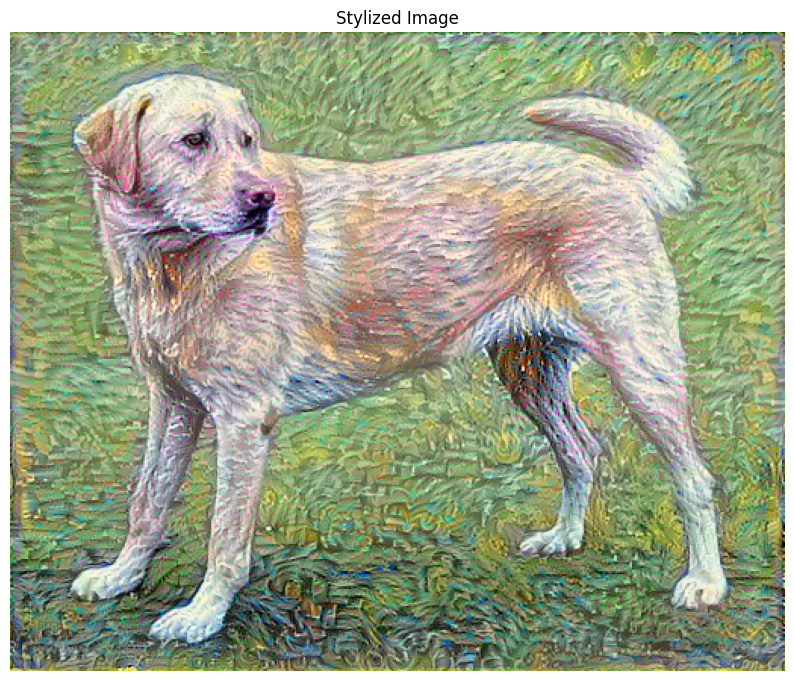

In [22]:
def deprocess_img(processed_img):
    x = processed_img.copy()
    x = x.reshape((x.shape[1], x.shape[2], 3))
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]
    x = np.clip(x, 0, 255).astype('uint8')
    return x

final_img = deprocess_img(best_img)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(final_img)
plt.axis('off')
plt.title("Stylized Image")
plt.show()

In [23]:
from PIL import Image

Image.fromarray(final_img).save("stylized_output.jpg")

In [24]:
from google.colab import files
files.download("stylized_output.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>